In [10]:
%load_ext autoreload
%autoreload 2

import os
import locomotif.locomotif as locomotif
from tqdm import tqdm
import pandas as pd

from tsmd_evaluation import evaluation
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
path_evaluataion = Path(tsmd_evaluation.__file__).parent.parent

In [3]:
locomotif.__file__

'c:\\Users\\arasy\\OneDrive - KU Leuven\\Research\\Motif Discovery\\LoCoMotif code\\locomotif_weakly_supervised\\locomotif\\locomotif.py'

In [4]:
def apply_locomotif_and_store_results(dataset, test=False, **locomotif_params):
    train_or_test = "test" if test else "train"
    filename = f"{train_or_test}_locomotif_" + "_".join([f"{key}={value}" for (key, value) in locomotif_params.items()]) + ".pkl"
    # path_to_result = os.path.join(".", "results", dataset.lower(), train_or_test, filename)
    path_to_result = os.path.join(path_evaluataion, "results", dataset.lower(), train_or_test, filename)

    # path_to_data = os.path.join("benchmarks", dataset.lower(), f"{train_or_test}.pkl")
    path_to_data = os.path.join(path_evaluataion, "benchmarks", dataset.lower(), f"{train_or_test}.pkl")
    df_ts = pd.read_pickle(path_to_data)

    if os.path.exists(path_to_result):
        # load and return result
        df_results  = pd.read_pickle(path_to_result)
        df_results = df_results.reset_index(drop=True)
        df = pd.concat((df_ts, df_results), axis=1)
        return df
    else:
        # apply
        results = []
        for row in tqdm(df_ts.iterrows()):
            series, _ = row[1]
            motif_sets = locomotif.apply_locomotif(series, print_progress=False, **locomotif_params)
            results.append(motif_sets)
            
        df_ts["MotifSets"] = results
        return df_ts

In [5]:
dataset = "CharacterTrajectories"
test    = False

locomotif_params = {'l_min': 83 , 'l_max': 142, 'rho': 0.8, 'warping': True, 'nb': 1}
df_result = apply_locomotif_and_store_results(dataset, test, **locomotif_params)

50it [10:17, 12.34s/it]


In [13]:
display(df_result)

,series,gt,MotifSets
0,"[[0.010513, 0.062652, 0.54173], [-0.015284, 0....","{'17': [(593, 691), (1024, 1118), (1635, 1730)...","[[(1233, 1317), (2515, 2615), (439, 531), (847..."
1,"[[-0.092072, -0.030451, 0.329069], [-0.106425,...","{'9': [(233, 373), (1169, 1309), (1667, 1822),...","[[(942, 1064), (3189, 3300), (3295, 3430), (22..."
2,"[[-0.066525, 0.119858, 0.714529], [-0.098222, ...","{'12': [(1886, 2023), (2944, 3076), (3189, 332...","[[(2673, 2800), (2417, 2563), (2145, 2271), (2..."
3,"[[0.001044, -2e-06, 0.430616], [0.003016, -1.3...","{'18': [(0, 165), (275, 378), (500, 655), (761...","[[(501, 587), (2007, 2097), (2, 102), (1483, 1..."
4,"[[1.5e-05, -0.037517, 0.78209], [8.8e-05, -0.0...","{'17': [(0, 102), (1031, 1140), (1501, 1599), ...","[[(581, 664), (2654, 2731), (3069, 3158), (126..."
5,"[[0.145837, 0.082692, 0.620186], [0.148309, 0....","{'2': [(391, 505), (634, 756), (1316, 1439), (...","[[(1316, 1401), (3529, 3629), (3029, 3122), (2..."
6,"[[0.083884, 0.006474, 0.477166], [0.060217, -0...","{'17': [(2023, 2126), (2263, 2365), (3637, 373...","[[(3397, 3481), (789, 873), (2907, 2983), (244..."
7,"[[-0.117315, 0.081475, 0.277411], [-0.185896, ...","{'5': [(743, 847), (974, 1080), (1441, 1557), ...","[[(384, 475), (2676, 2793), (3686, 3775), (616..."
8,"[[-2e-06, -0.000106, 0.407239], [-1.7e-05, -0....","{'19': [(271, 396), (1230, 1343)], '12': [(0, ...","[[(2997, 3080), (3264, 3340), (1117, 1187), (1..."
9,"[[-0.003798, 0.025957, 0.459193], [-0.009942, ...","{'18': [(429, 535), (1991, 2104), (2221, 2332)...","[[(542, 636), (2817, 2912), (2336, 2407), (258..."


+----+----+----+
|    |  1 | MD |
+----+----+----+
| 3  | 10 | 2  |
+----+----+----+
| 17 |  0 | 6  |
+----+----+----+
| FD |  6 | -  |
+----+----+----+
0.625
0.5555555555555556
0.5882352941176471


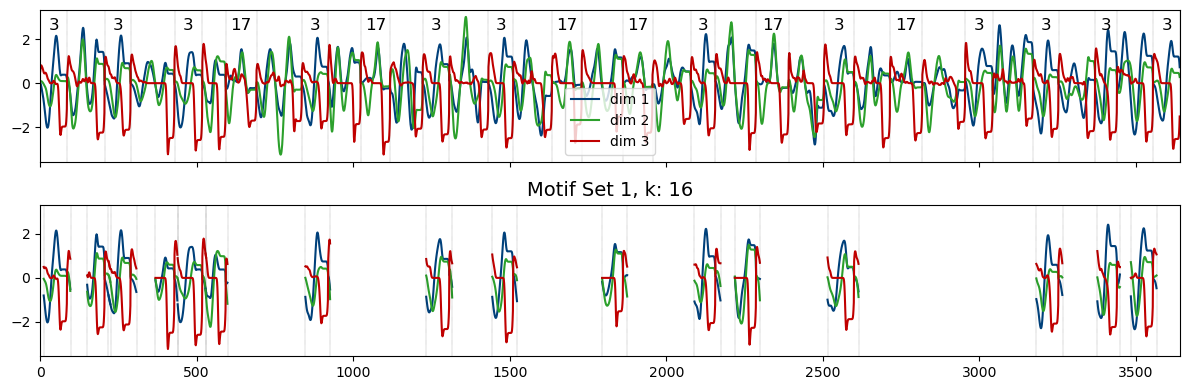

In [11]:
ts, gt, motif_sets, *_ = df_result.iloc[0]

import locomotif.visualize as vis
import matplotlib.pyplot as plt

mm, row_names, col_names = evaluation.match_matrix(gt, motif_sets)
print(evaluation.pretty_print_match_matrix(mm, row_names, col_names))

print(evaluation.precision(mm))
print(evaluation.recall(mm))
print(evaluation.f1_score(mm))

vis.plot_motif_sets(ts, motif_sets, gt)
plt.show()